## Bluestock Mutual Fund Analytics

## Exploratory Data Analysis (EDA)

### Internship Capstone Project

**Prepared By:**
**Jaydeep Dhurat**

**( Data Analyst & Data Engineering Intern At Bluestock Fintech Pvt Ltd.)**

---

**This notebook presents an exploratory data analysis of the Bluestock Mutual Fund Analytics dataset. The objective is to understand fund performance, investor behaviour, market trends, portfolio allocation, and key business insights through statistical analysis and interactive visualizations.**

Tools Used Are:

1) Python
2) Pandas
3) Plotly
4) Matplotlib
5) Seaborn
6) NumPy





In [1]:
# ==========================================================
# Importing Required Libraries & Packages
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Matplotlib settings
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

print("Libraries Imported Successfully")



Libraries Imported Successfully


In [2]:
# ==========================================================
# Loaded All Cleaned Datasets From Processed Folder
# ==========================================================

from pathlib import Path

DATA_PATH = Path("../data/processed")

fund_master = pd.read_csv(DATA_PATH / "01_fund_master_clean.csv")
nav_history = pd.read_csv(DATA_PATH / "02_nav_history_clean.csv")
aum = pd.read_csv(DATA_PATH / "03_aum_by_fund_house_clean.csv")
sip = pd.read_csv(DATA_PATH / "04_monthly_sip_inflows_clean.csv")
category = pd.read_csv(DATA_PATH / "05_category_inflows_clean.csv")
folio = pd.read_csv(DATA_PATH / "06_industry_folio_count_clean.csv")
performance = pd.read_csv(DATA_PATH / "07_scheme_performance_clean.csv")
transactions = pd.read_csv(DATA_PATH / "08_investor_transactions_clean.csv")
portfolio = pd.read_csv(DATA_PATH / "09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv(DATA_PATH / "10_benchmark_indices_clean.csv")

print("✅ All cleaned datasets loaded successfully!")



✅ All cleaned datasets loaded successfully!


In [3]:
# ==========================================================
# Creating A Professional Dataset Overview So We Can Actually Analyse & Explore The Datasets.
# ==========================================================

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM by Fund House": aum,
    "Monthly SIP": sip,
    "Category Inflows": category,
    "Industry Folio": folio,
    "Scheme Performance": performance,
    "Investor Transactions": transactions,
    "Portfolio Holdings": portfolio,
    "Benchmark Indices": benchmark
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Memory (KB)": [round(df.memory_usage(deep=True).sum()/1024, 2) for df in datasets.values()]
})

summary

,Dataset,Rows,Columns,Memory (KB)
0,Fund Master,40,15,25.94
1,NAV History,46000,3,3369.27
2,AUM by Fund House,90,5,13.19
3,Monthly SIP,48,6,4.63
4,Category Inflows,144,3,17.33
5,Industry Folio,21,6,2.10
6,Scheme Performance,40,19,17.20
7,Investor Transactions,32778,13,18624.46
8,Portfolio Holdings,322,8,85.14
9,Benchmark Indices,8050,3,995.15


## Dataset Overview

The capstone internship project consists of ten cleaned datasets covering mutual fund schemes, NAV history, AUM, SIP inflows, investor transactions, portfolio holdings, benchmark indices, and industry statistics. These datasets collectively support trend analysis, investor behaviour analysis, performance evaluation, and portfolio analytics.

**Key Observations**

1) Total datasets analysed: **10**
2) Largest dataset: **NAV History**
3) Investor transaction records provide transaction level behavioural insights.
4) Portfolio holdings enable sector allocation analysis.
5) Historical NAV and benchmark data support time series performance evaluation.


### 1. NAV Trend Analysis

### Objective

**Analyze the daily Net Asset Value (NAV) movement of all 40 mutual fund schemes from January 2022 to December 2026. The visualization highlights the broad market uptrend during 2023 and the market correction observed during 2024.**

**Business Question**

**1) How have NAV values evolved over time?**
**2) Which schemes experienced the strongest growth?**
**3) Are market wide trends visible across all schemes?**

In [4]:
# ==========================================================
# Preparing The NAV Historical Data
# ==========================================================

# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort values
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

print("NAV Dataset Shape:", nav_history.shape)

print("\nDate Range:")
print(nav_history["date"].min())
print(nav_history["date"].max())

print("\nNumber of Schemes:")
print(nav_history["amfi_code"].nunique())

NAV Dataset Shape: (46000, 3)

Date Range:
2022-01-03 00:00:00
2026-05-29 00:00:00

Number of Schemes:
40


## **NAV Trend Analysis: Plot Daily NAV For All 40 Schemes 2022–2026. Highlight 2023 Bull Run And 2024 Market Corrections Using Plotly.**


In [15]:
# ==========================================================
# Creating Interactive NAV Trend Analysis (All 40 Schemes)
# ==========================================================

# Merge scheme names
nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Create interactive line chart
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (₹)",
        "scheme_name": "Scheme"
    },
    template="plotly_white"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    line_width=0
)

# Improve layout
fig.update_layout(
    height=700,
    hovermode="closest",
    title_x=0.5,
    legend_title="Mutual Fund Schemes"
)

fig.update_xaxes(
    range=[
        "2022-01-01",
        "2026-06-01"
    ]
)

# Save Interactive HTML
fig.write_html(
    CHART_DIR / "01_nav_trend_analysis.html"
)

# Save High Resolution PNG
fig.write_image(
    CHART_DIR / "01_nav_trend_analysis.png",
    width=1800,
    height=900,
    scale=2
)

fig.show()


from pathlib import Path

CHART_DIR = Path("../dashboard/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

fig.write_image(
    CHART_DIR / "01_nav_trend_analysis.png",
    width=1800,
    height=900,
    scale=2
)

### **Business Interpretation**

**The interactive NAV trend analysis demonstrates the long term performance trajectory of all 40 mutual fund schemes between 2022 and 2026.**

**The shaded green region represents the strong equity market rally observed during 2023, where most schemes exhibited sustained NAV appreciation. The red region highlights the market correction period during 2024, during which several schemes experienced temporary declines before resuming growth.**

**Overall, the visualization indicates that the majority of equity oriented schemes recovered from short term corrections and continued their long term upward trend, reinforcing the importance of disciplined long term investing.**

## **Key Observations**

1) The dataset contains daily NAV history for **40 mutual fund schemes** covering the period from **January 2022 to May 2026**.
2) Most equity oriented schemes experienced consistent NAV appreciation during the **2023 market rally**, indicating broad based market participation.
3) A temporary slowdown and correction is visible across several schemes during **2024**, after which most funds resumed their upward trajectory.
4) Considerable variation exists in absolute NAV values because schemes were launched at different times and have different historical growth trajectories.

## **Business Insight**

Long term investment strategies generally outperformed short-term market fluctuations. Despite temporary corrections, the majority of mutual fund schemes demonstrated resilience and sustained long term value creation.

## **Recommendation**

Future performance comparisons should use **normalized NAV** or **percentage returns** instead of absolute NAV values to enable fair comparison across schemes with different starting NAV levels.

In [6]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [7]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [8]:
# ==========================================================
# Preparing AUM Dataset
# ==========================================================

# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year from date
aum["year"] = aum["date"].dt.year

# Verify the new column
print(aum.head())

print("\nColumns:")
print(aum.columns.tolist())

print("\nUnique Years:")
print(aum["year"].unique())

print("\nNumber of Fund Houses:")
print(aum["fund_house"].nunique())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  year
0 2022-03-31      SBI Mutual Fund            6.05     605000          186  2022
1 2022-03-31  ICICI Prudential MF            4.65     465000          216  2022
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195  2022
3 2022-03-31      Nippon India MF            2.70     270000          177  2022
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168  2022

Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']

Unique Years:
[2022 2023 2024 2025]

Number of Fund Houses:
10


In [9]:
aum_2025 = (
    aum[aum["year"] == 2025]
    .sort_values("aum_lakh_crore", ascending=False)
)

print(aum_2025)

         date                fund_house  aum_lakh_crore  aum_crore  num_schemes  year
70 2025-03-31           SBI Mutual Fund           12.50    1250000          186  2025
80 2025-12-31           SBI Mutual Fund           12.50    1250000          186  2025
81 2025-12-31       ICICI Prudential MF           10.74    1074000          216  2025
82 2025-12-31          HDFC Mutual Fund            9.30     930000          195  2025
71 2025-03-31       ICICI Prudential MF            8.80     880000          216  2025
72 2025-03-31          HDFC Mutual Fund            7.95     795000          195  2025
83 2025-12-31           Nippon India MF            7.00     700000          177  2025
84 2025-12-31         Kotak Mahindra MF            5.80     580000          168  2025
73 2025-03-31           Nippon India MF            5.60     560000          177  2025
74 2025-03-31         Kotak Mahindra MF            4.92     492000          168  2025
85 2025-12-31  Aditya Birla Sun Life MF            4.6

In [10]:
print(aum_2025[["fund_house", "aum_lakh_crore"]])

                  fund_house  aum_lakh_crore
70           SBI Mutual Fund           12.50
80           SBI Mutual Fund           12.50
81       ICICI Prudential MF           10.74
82          HDFC Mutual Fund            9.30
71       ICICI Prudential MF            8.80
72          HDFC Mutual Fund            7.95
83           Nippon India MF            7.00
84         Kotak Mahindra MF            5.80
73           Nippon India MF            5.60
74         Kotak Mahindra MF            4.92
85  Aditya Birla Sun Life MF            4.60
87           UTI Mutual Fund            4.10
75  Aditya Birla Sun Life MF            3.85
77           UTI Mutual Fund            3.55
86          Axis Mutual Fund            3.50
76          Axis Mutual Fund            3.10
88            Mirae Asset MF            2.90
89           DSP Mutual Fund            2.30
78            Mirae Asset MF            2.25
79           DSP Mutual Fund            1.95


In [11]:
print(
    aum.groupby("year")["date"].unique()
)

year
2022           [2022-03-31 00:00:00, 2022-09-30 00:00:00]
2023           [2023-03-31 00:00:00, 2023-09-30 00:00:00]
2024    [2024-03-31 00:00:00, 2024-09-30 00:00:00, 202...
2025           [2025-03-31 00:00:00, 2025-12-31 00:00:00]
Name: date, dtype: object


In [12]:
# ==========================================================
# Creating The Annual AUM Dataset
# Keep the latest available record for each year
# ==========================================================

# Sort by date
aum = aum.sort_values("date")

# Keep latest record for each Fund House and Year
aum_annual = (
    aum
    .groupby(["year", "fund_house"], as_index=False)
    .last()
)

print(aum_annual.head())

print("\nShape:")
print(aum_annual.shape)

   year                fund_house       date  aum_lakh_crore  aum_crore  num_schemes
0  2022  Aditya Birla Sun Life MF 2022-09-30            2.85     285000          199
1  2022          Axis Mutual Fund 2022-09-30            2.40     240000           95
2  2022           DSP Mutual Fund 2022-09-30            1.12     112000           88
3  2022          HDFC Mutual Fund 2022-09-30            4.45     445000          195
4  2022       ICICI Prudential MF 2022-09-30            4.88     488000          216

Shape:
(40, 6)


In [13]:
print(
    aum_annual[aum_annual["year"] == 2025]
    .sort_values("aum_lakh_crore", ascending=False)
)

    year                fund_house       date  aum_lakh_crore  aum_crore  num_schemes
38  2025           SBI Mutual Fund 2025-12-31           12.50    1250000          186
34  2025       ICICI Prudential MF 2025-12-31           10.74    1074000          216
33  2025          HDFC Mutual Fund 2025-12-31            9.30     930000          195
37  2025           Nippon India MF 2025-12-31            7.00     700000          177
35  2025         Kotak Mahindra MF 2025-12-31            5.80     580000          168
30  2025  Aditya Birla Sun Life MF 2025-12-31            4.60     460000          199
39  2025           UTI Mutual Fund 2025-12-31            4.10     410000          142
31  2025          Axis Mutual Fund 2025-12-31            3.50     350000           95
36  2025            Mirae Asset MF 2025-12-31            2.90     290000           56
32  2025           DSP Mutual Fund 2025-12-31            2.30     230000           88


## **AUM Growth Bar Chart: Grouped Bar By Fund House For Each Year 2022–2025. Highlight SBI At ₹12.5L Cr Dominance Using Seaborn.**

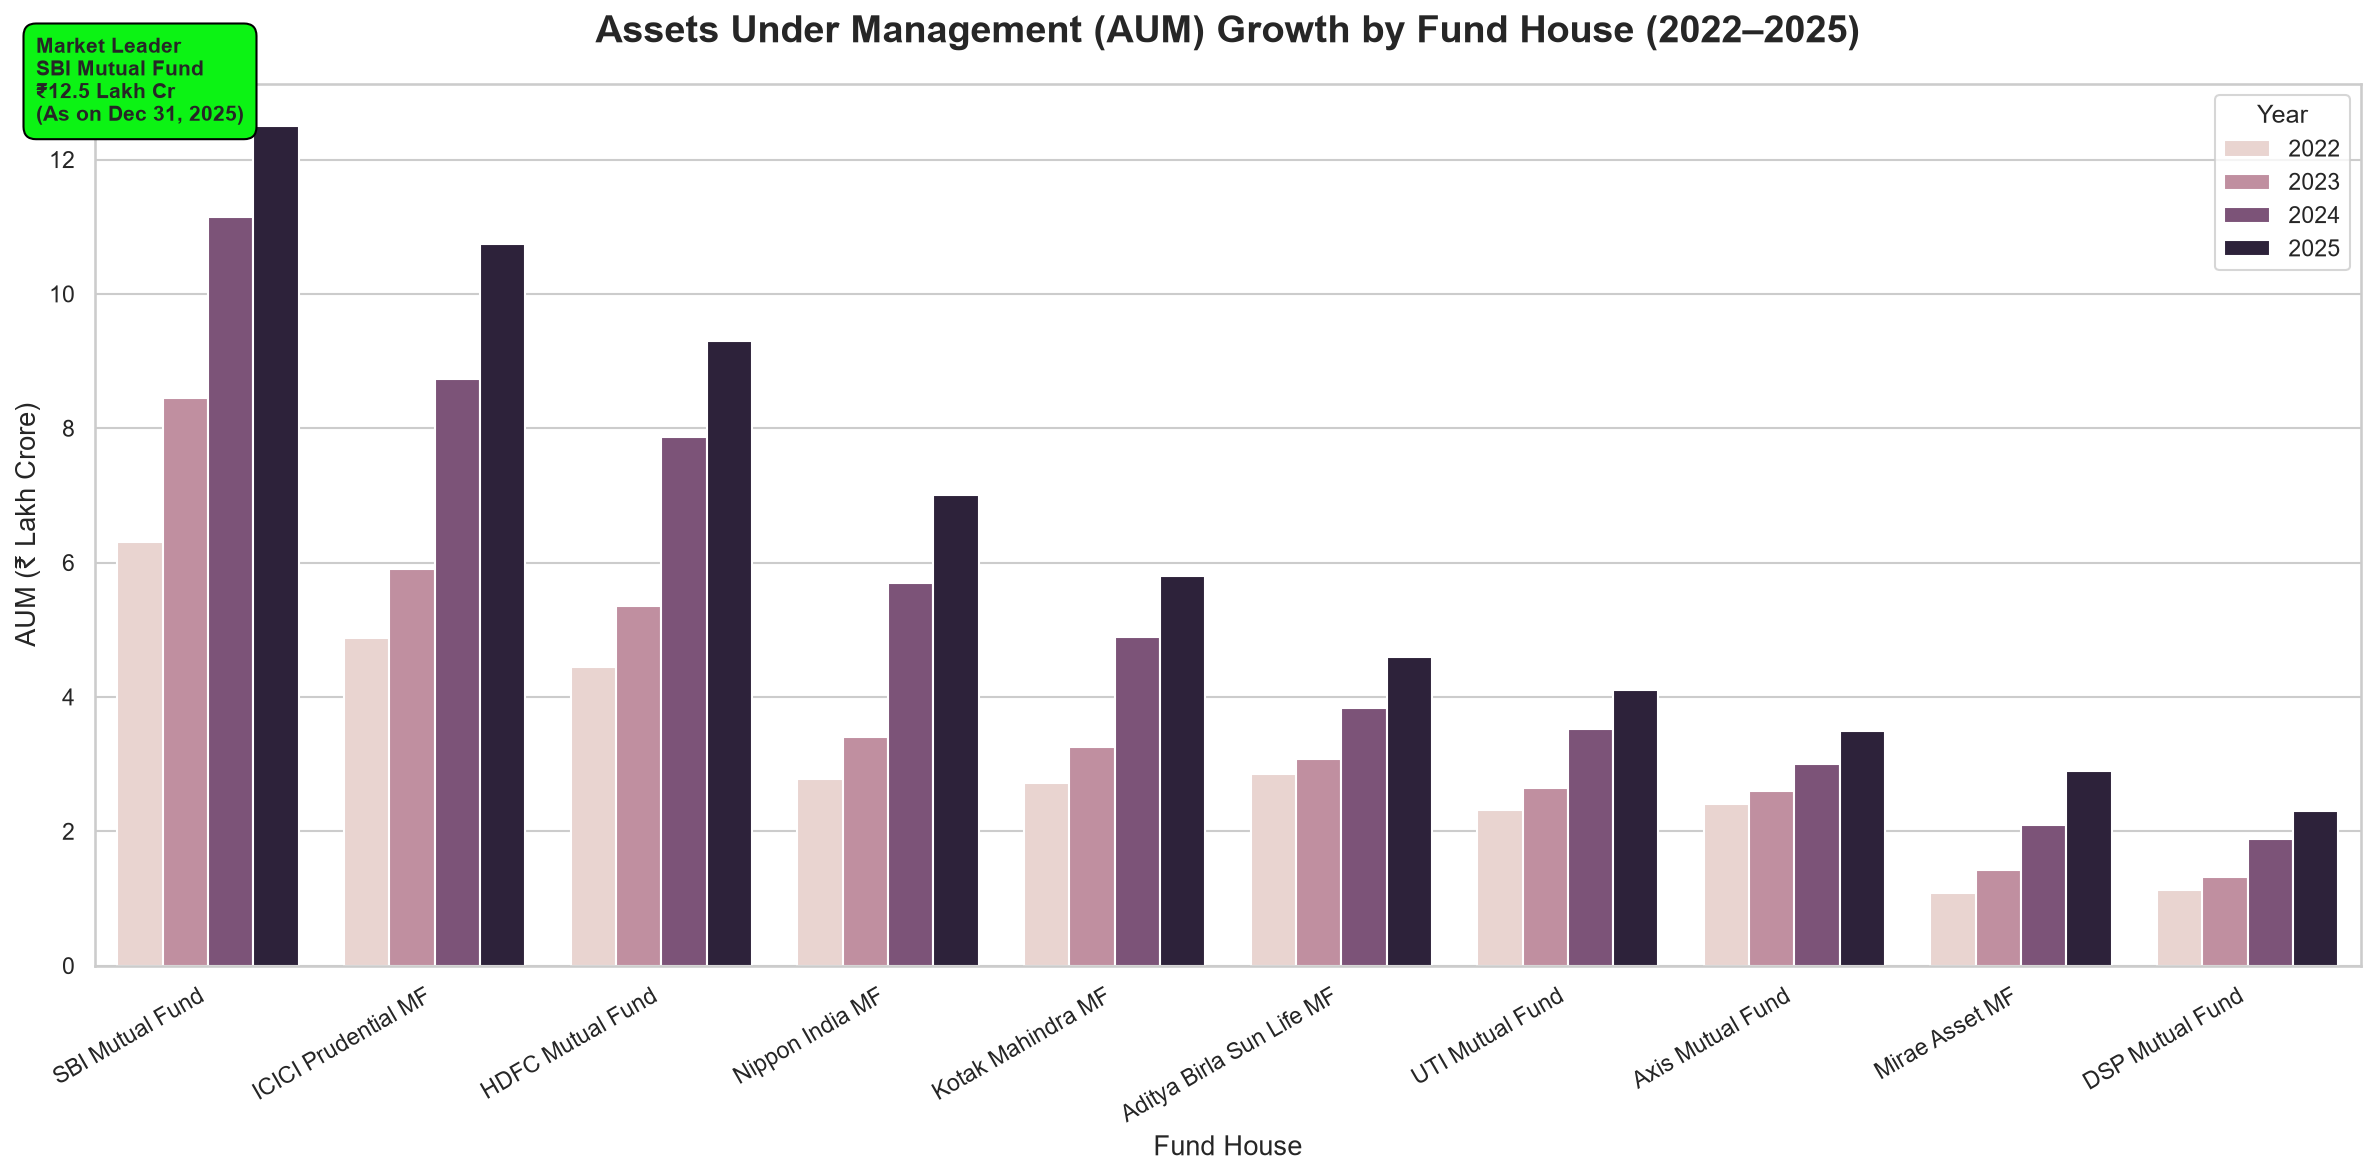

In [14]:
# ==========================================================
# AUM Growth by Fund House (2022–2025)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style
sns.set_theme(style="whitegrid")

# Sort fund houses by 2025 AUM
fund_order = (
    aum_annual[aum_annual["year"] == 2025]
    .sort_values("aum_lakh_crore", ascending=False)["fund_house"]
)

# Create figure
plt.figure(figsize=(16, 8))

# Draw grouped bar chart
ax = sns.barplot(
    data=aum_annual,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    order=fund_order
)

# Title
plt.title(
    "Assets Under Management (AUM) Growth by Fund House (2022–2025)",
    fontsize=18,
    weight="bold",
    pad=20
)

# Axis Labels
plt.xlabel("Fund House", fontsize=13)
plt.ylabel("AUM (₹ Lakh Crore)", fontsize=13)

# Rotate labels
plt.xticks(rotation=30, ha="right")

# Legend
plt.legend(title="Year")

# ==========================================================
# KPI Box (Top Left Corner)
# ==========================================================

plt.figtext(
    0.02,      # X position
    0.96,      # Y position
    "Market Leader\n"
    "SBI Mutual Fund\n"
    "₹12.5 Lakh Cr\n"
    "(As on Dec 31, 2025)",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top",
    bbox=dict(
        facecolor="#0CF314",
        edgecolor="black",
        boxstyle="round,pad=0.6"
    )
)

plt.tight_layout()

from pathlib import Path

CHART_DIR = Path("../dashboard/charts")

CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    CHART_DIR / "02_aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [16]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [17]:
# ==========================================================
# SIP INFLOW TREND ANALYSIS
# ==========================================================

# Convert month column into datetime

sip["month"] = pd.to_datetime(sip["month"])

# Verify

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [18]:
# Highest SIP inflow

peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [24]:
peak_date = peak["month"].strftime("%Y-%m-%d")

In [19]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows in India (Jan 2022 – Dec 2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    },
    template="plotly_white"
)

In [20]:
fig.update_layout(

    title={
        "text":"Monthly SIP Inflows (2022–2025)",
        "x":0.5,
        "xanchor":"center"
    },

    font=dict(size=14),

    hovermode="x unified",

    width=1200,
    height=600,

    xaxis_title="Month",

    yaxis_title="SIP Inflow (₹ Crore)"
)

## **SIP Inflow Time Series: Monthly SIP Trend Jan 2022 – Dec 2025. Annotate The ₹31,002 Cr All Time High (Dec 2025) Using Plotly.**

In [25]:
fig.add_scatter(

    x=[peak_date],

    y=[peak["sip_inflow_crore"]],

    mode="markers",

    marker=dict(
        size=14,
        color="red"
    ),

    name="All-Time High"
)

In [27]:
fig.add_annotation(

    x=peak_date,

    y=peak["sip_inflow_crore"],

    text="₹31,002 Cr<br>Dec 2025",

    showarrow=True,

    arrowhead=3,

    ax=-40,

    ay=-80,

    bgcolor="yellow",

    bordercolor="black",

    font=dict(
        size=12
    )
)

In [29]:
import plotly
import kaleido
import pandas as pd

print("Plotly :", plotly.__version__)
print("Kaleido:", kaleido.__version__)
print("Pandas :", pd.__version__)

Plotly : 6.8.0


AttributeError: module 'kaleido' has no attribute '__version__'

In [30]:
print(type(peak_date))
print(peak_date)

<class 'str'>
2025-12-01


In [31]:
print(sip["month"].dtype)

datetime64[us]


In [32]:
# Convert datetime64[us] -> datetime64[ns]
sip["month"] = sip["month"].astype("datetime64[ns]")

print(sip["month"].dtype)

datetime64[ns]


In [41]:
import plotly.io as pio

# This uses Kaleido directly
img_bytes = pio.to_image(fig, format="png")

print("Image generated successfully!")

Image generated successfully!


In [34]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar"],
    "Value": [10, 20, 30]
})

fig = px.line(df, x="Month", y="Value")

fig.write_image("simple_test.png")

print("Success!")

Success!


In [35]:
print(type(peak["sip_inflow_crore"]))
print(type(peak["month"]))
print(type(peak_date))

<class 'numpy.int64'>
<class 'pandas.Timestamp'>
<class 'str'>


In [40]:
import json
import pandas as pd
import plotly
import numpy as np

print("=" * 70)
print("PLOTLY FIGURE DIAGNOSTICS")
print("=" * 70)

print(f"Plotly Version : {plotly.__version__}")
print(f"SIP month dtype: {sip['month'].dtype}")

print("\nChecking figure serialization...")

try:
    fig_dict = fig.to_plotly_json()
    print("✅ Figure converted to Plotly JSON successfully.")
except Exception as e:
    print("❌ Error converting figure:")
    print(e)

print("\nSearching for Timestamp objects...")

def find_timestamps(obj, path="root"):
    if isinstance(obj, pd.Timestamp):
        print(f"❌ Timestamp found at: {path} -> {obj}")

    elif isinstance(obj, dict):
        for k, v in obj.items():
            find_timestamps(v, f"{path}.{k}")

    elif isinstance(obj, (list, tuple)):
        for i, item in enumerate(obj):
            find_timestamps(item, f"{path}[{i}]")

try:
    find_timestamps(fig.to_plotly_json())
    print("✅ Timestamp scan completed.")
except Exception as e:
    print("Scan Error:", e)

print("\nAttempting JSON serialization...")

try:
    json.dumps(fig.to_plotly_json(), default=str)
    print("✅ JSON serialization successful.")
except Exception as e:
    print("❌ JSON serialization failed:")
    print(e)

print("\nFigure Summary")
print("-" * 70)
print(f"Number of traces : {len(fig.data)}")

for i, trace in enumerate(fig.data):
    print(f"\nTrace {i+1}")
    print("Type :", trace.type)
    print("Name :", trace.name)

    try:
        print("X datatype :", type(trace.x[0]))
    except:
        pass

    try:
        print("Y datatype :", type(trace.y[0]))
    except:
        pass

print("=" * 70)
print("Diagnostics Complete")
print("=" * 70)

PLOTLY FIGURE DIAGNOSTICS
Plotly Version : 6.8.0
SIP month dtype: datetime64[ns]

Checking figure serialization...
✅ Figure converted to Plotly JSON successfully.

Searching for Timestamp objects...
✅ Timestamp scan completed.

Attempting JSON serialization...
✅ JSON serialization successful.

Figure Summary
----------------------------------------------------------------------
Number of traces : 2

Trace 1
Type : scatter
Name : 
X datatype : <class 'numpy.datetime64'>
Y datatype : <class 'numpy.int64'>

Trace 2
Type : scatter
Name : None
X datatype : <class 'str'>
Y datatype : <class 'int'>
Diagnostics Complete


In [43]:
for col in df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns:
    df[col] = df[col].astype(str)

In [44]:
print(df.dtypes)

Month      str
Value    int64
dtype: object


In [45]:
fig.write_image(
    CHART_DIR / "03_sip_inflow_trend.png",
    width=1800,
    height=900,
    scale=2
)

In [60]:
df = category.copy()

In [62]:
df["month"] = pd.to_datetime(df["month"])

In [63]:
df["month_label"] = df["month"].dt.strftime("%Y-%m")

In [67]:
print(df.columns.tolist())

['month', 'category', 'net_inflow_crore', 'month_label']


In [68]:
heatmap_data = df.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

## **Category Inflow Heatmap: Months On X-Axis, Fund Categories On Y-Axis, Net Inflow As Colour Intensity Using Seaborn.**

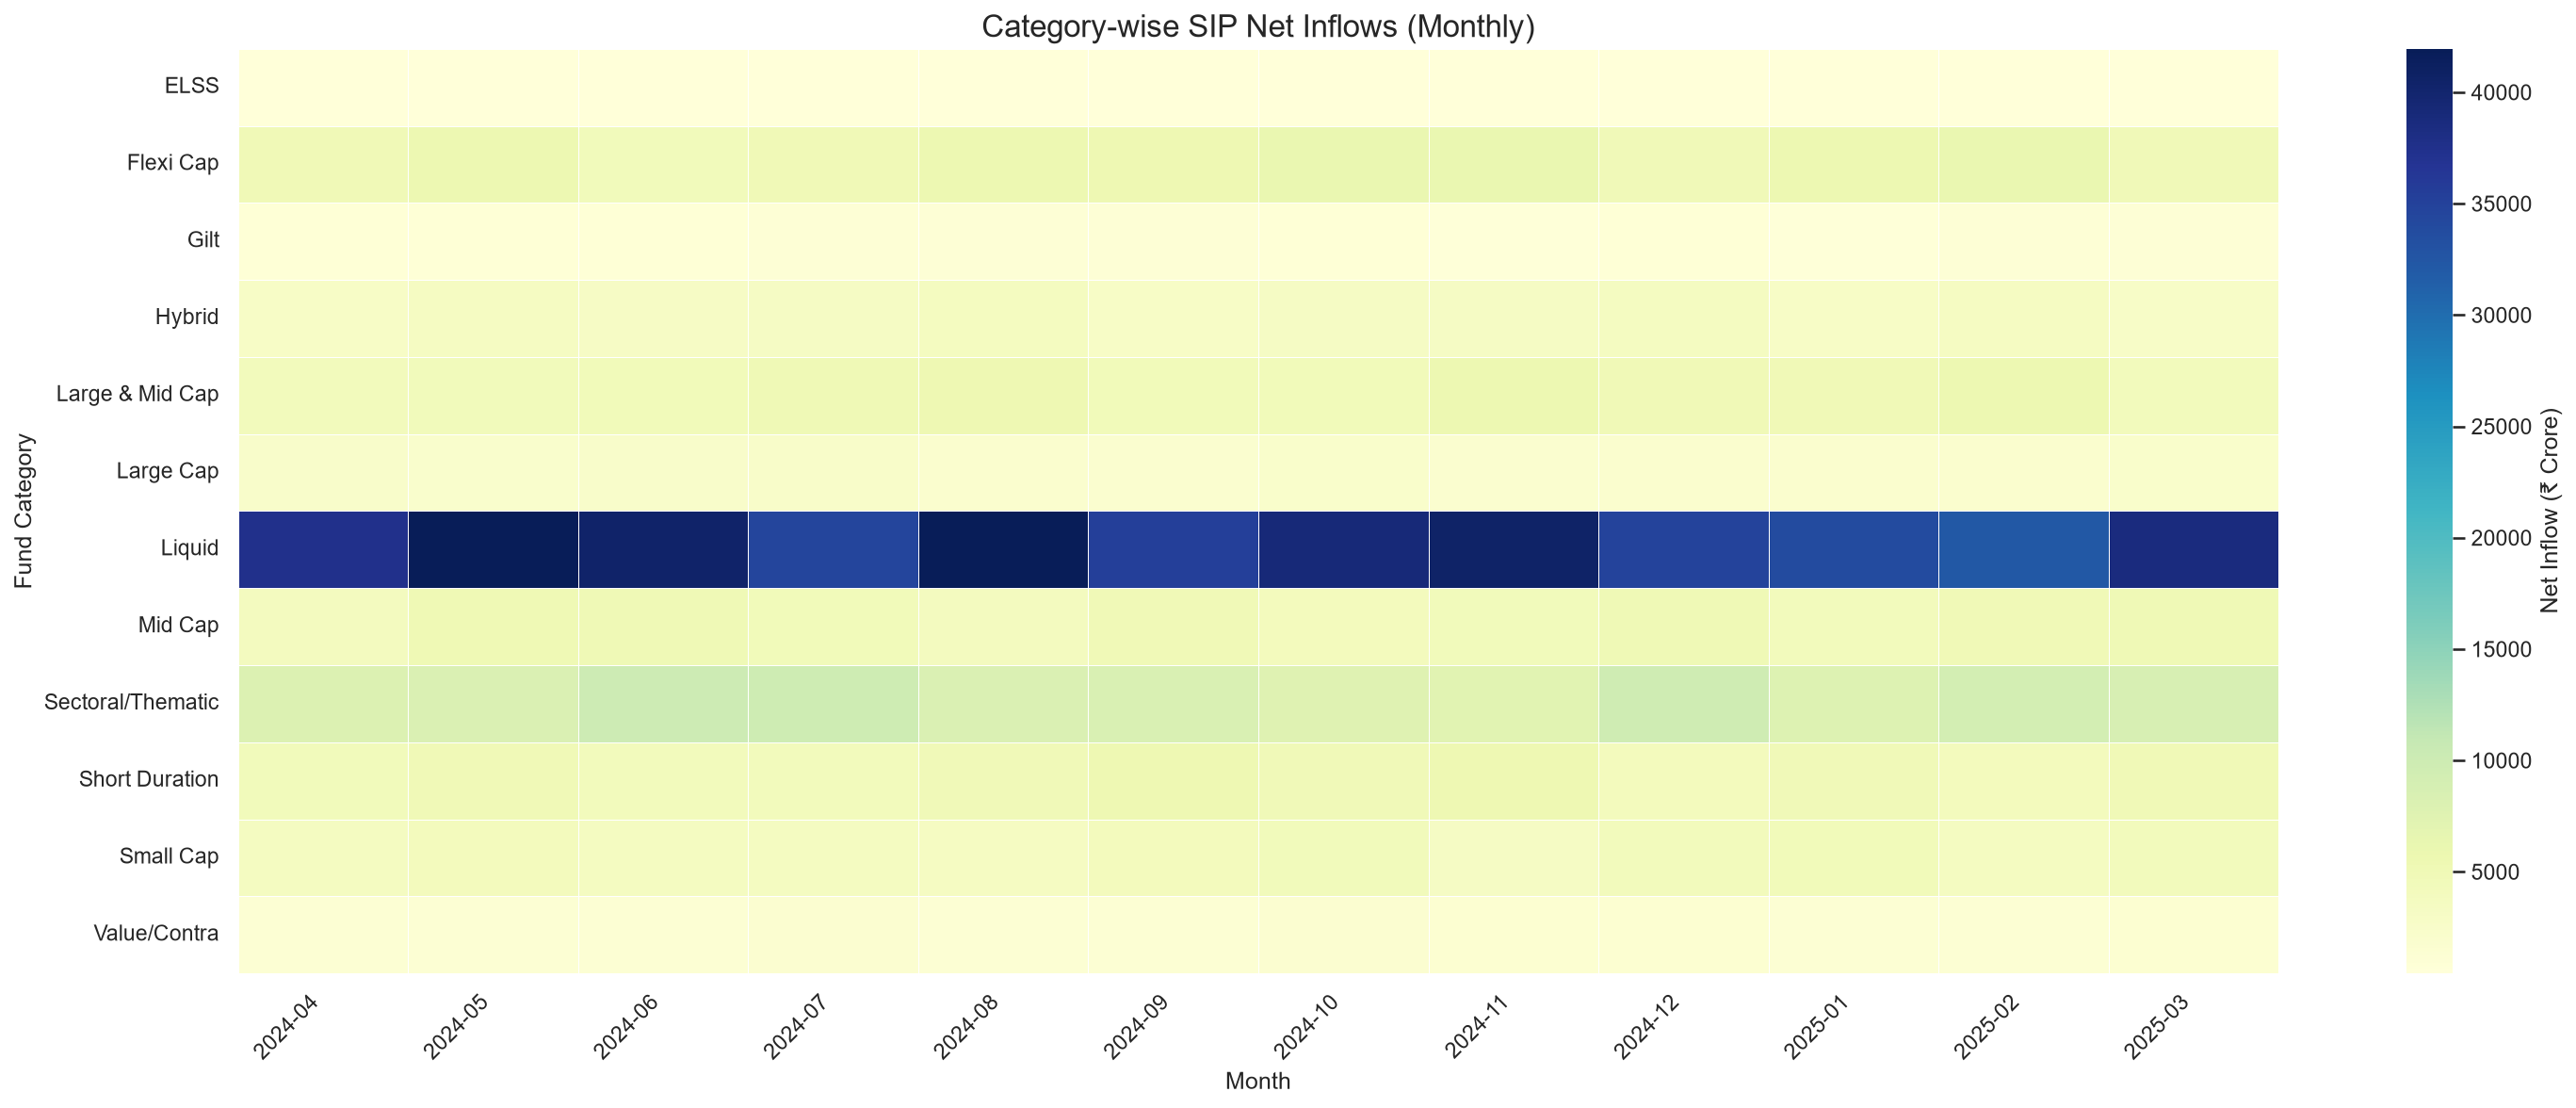

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title("Category-wise SIP Net Inflows (Monthly)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

from pathlib import Path

CHART_DIR = Path("../dashboard/charts")

CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    CHART_DIR / "05_category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)



plt.show()

In [79]:
import plotly.express as px

fig = px.imshow(
    heatmap_data,
    color_continuous_scale="YlGnBu",
    aspect="auto",
    title="Category-wise SIP Net Inflows (Monthly)"
)

In [80]:
from pathlib import Path

CHART_DIR = Path("../dashboard/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

fig.write_html(CHART_DIR / "05_category_inflow_heatmap.html")

In [81]:
fig.write_html(
    CHART_DIR / "05_category_inflow_heatmap.html",
    include_plotlyjs="cdn",
    full_html=True
)

In [82]:
df = transactions.copy()

In [83]:
print(df.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [86]:
import pandas as pd

df_demo = transactions.copy()  # replace with your actual dataframe name

In [87]:
age_df = df_demo.groupby("age_group")["investor_id"].nunique().reset_index()

age_df.columns = ["age_group", "investor_count"]

In [88]:
fig = px.pie(
    age_df,
    names="age_group",
    values="investor_count",
    title="Investor Age Group Distribution",
    hole=0.35
)

## **Investor Demographics: Age Group Distribution Pie Chart. SIP Amount Box Plot By Age Group. Gender Split.**

In [89]:
fig.update_traces(textinfo="percent+label")

fig.update_layout(
    template="plotly_white",
    title_font_size=20
)

In [90]:
from pathlib import Path

CHART_DIR = Path("../dashboard/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

fig.write_image(CHART_DIR / "07_age_distribution.png", width=1200, height=800)
fig.write_html(CHART_DIR / "07_age_distribution.html")

In [91]:
fig2 = px.box(
    df_demo,
    x="age_group",
    y="amount_inr",
    title="SIP Amount Distribution by Age Group"
)

In [92]:
fig2.write_image(CHART_DIR / "08_sip_box_by_age.png", width=1200, height=800)
fig2.write_html(CHART_DIR / "08_sip_box_by_age.html")

In [93]:
gender_df = df_demo.groupby("gender")["investor_id"].nunique().reset_index()

gender_df.columns = ["gender", "count"]

In [94]:
fig3 = px.pie(
    gender_df,
    names="gender",
    values="count",
    title="Investor Gender Distribution",
    hole=0.3
)

In [95]:
fig3.write_image(CHART_DIR / "09_gender_distribution.png", width=1200, height=800)
fig3.write_html(CHART_DIR / "09_gender_distribution.html")

In [96]:
import pandas as pd

df_geo = transactions.copy()

In [101]:
state_df = (
    df_geo.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)   
    .reset_index()
)

## **Geographic Distribution: Horizontal Bar Chart Of SIP Amount By State. T30 vs B30 City Tier Pie Chart.**

In [102]:
import plotly.express as px

fig = px.bar(
    state_df,
    x="state",
    y="amount_inr",
    title="Top 10 States by SIP Amount",
    text="amount_inr"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="State",
    yaxis_title="SIP Amount (₹)",
    xaxis_tickangle=-45
)

fig.show()

In [103]:
from pathlib import Path

CHART_DIR = Path("../dashboard/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

fig.write_image(CHART_DIR / "10_state_sip_bar.png", width=1400, height=800)
fig.write_html(CHART_DIR / "10_state_sip_bar.html")

In [104]:
import pandas as pd

df_geo = transactions.copy()

In [105]:
tier_df = (
    df_geo.groupby("city_tier")["amount_inr"]
    .sum()
    .reset_index()
)

In [106]:
import plotly.express as px

fig = px.pie(
    tier_df,
    names="city_tier",
    values="amount_inr",
    title="T30 vs B30 SIP Distribution",
    hole=0.35
)

fig.update_traces(textinfo="percent+label")
fig.update_layout(template="plotly_white")

fig.show()

In [107]:
from pathlib import Path

CHART_DIR = Path("../dashboard/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

fig.write_image(CHART_DIR / "11_t30_b30_split.png", width=1200, height=800)
fig.write_html(CHART_DIR / "11_t30_b30_split.html")

In [111]:
import pandas as pd

df_folio = folio.copy()

df_folio.columns = df_folio.columns.str.strip()
df_folio["month"] = pd.to_datetime(df_folio["month"])

df_folio = df_folio.sort_values("month")

In [117]:
import plotly.express as px



df_folio = folio.copy()

df_folio.columns = df_folio.columns.str.strip()

df_folio["month"] = pd.to_datetime(df_folio["month"])

# CRITICAL FIX
df_folio["month"] = df_folio["month"].dt.strftime("%Y-%m")

df_folio = df_folio.sort_values("month")

df_melt = df_folio.melt(
    id_vars="month",
    value_vars=[
        "total_folios_crore",
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore",
        "others_folios_crore"
    ],
    var_name="folio_type",
    value_name="value"
)

fig = px.line(
    df_melt,
    x="month",
    y="value",
    color="folio_type",
    title="Folio Growth by Category (2022–2025)",
    markers=True
)

## **Folio Count Growth: Line Chart From 13.26 Cr (Jan 2022) To 26.12 Cr (Dec 2025). Mark Key Milestones.**

In [118]:
import plotly.express as px

fig = px.line(
    df_melt,
    x="month",
    y="value",
    color="folio_type",
    title="Folio Growth by Category (2022–2025)",
    markers=True
)

fig.update_layout(template="plotly_white")

In [119]:
from pathlib import Path

CHART_DIR = Path("../dashboard/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

fig.write_image(CHART_DIR / "12_folio_growth_multi.png", width=1600, height=900)
fig.write_html(CHART_DIR / "12_folio_growth_multi.html")

In [120]:
nav_history.columns.tolist()

['amfi_code', 'date', 'nav']

In [121]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [122]:
df_nav = nav_history.copy()

In [123]:
df_nav.columns = df_nav.columns.str.strip()

df_nav["date"] = pd.to_datetime(df_nav["date"])

df_nav = df_nav.sort_values(
    by=["amfi_code", "date"]
)

In [124]:
selected_funds = (
    df_nav["amfi_code"]
    .drop_duplicates()
    .sort_values()
    .head(10)
)

selected_funds

0        100016
1150     100025
2300     100033
3450     101206
4600     101207
5750     101208
6900     102885
8050     102886
9200     102887
10350    118632
Name: amfi_code, dtype: int64

In [125]:
df_selected = df_nav[
    df_nav["amfi_code"].isin(selected_funds)
]

In [126]:
nav_matrix = df_selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [127]:
nav_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [128]:
daily_returns = nav_matrix.pct_change().dropna()

In [129]:
corr_matrix = daily_returns.corr()

corr_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384


## **NAV Return Correlation Matrix: Compute Pairwise Correlation Of Daily Returns For 10 Selected Funds. Seaborn Heatmap.**

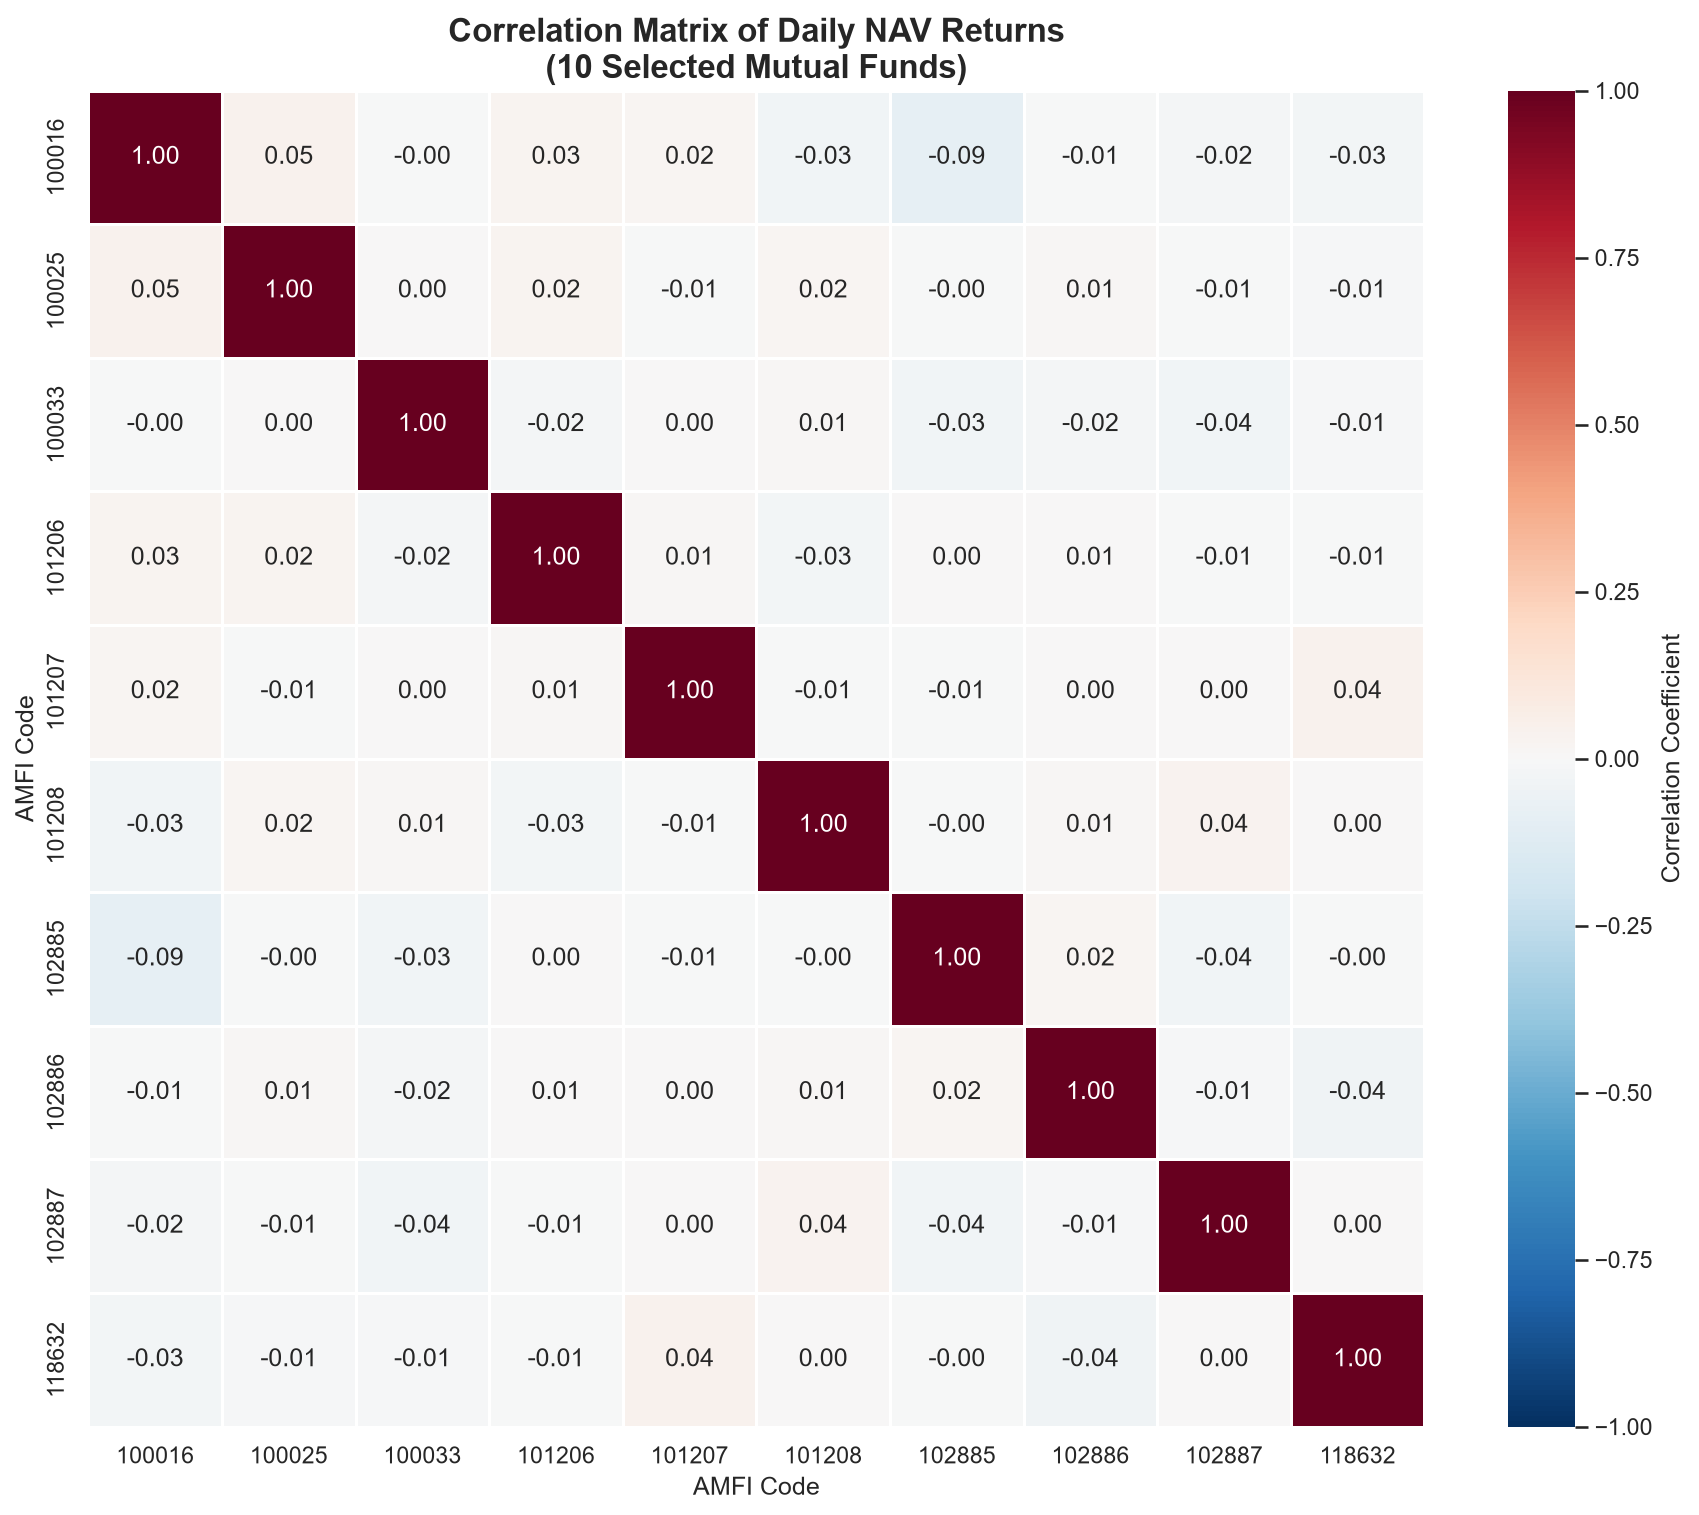

In [130]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title(
    "Correlation Matrix of Daily NAV Returns\n(10 Selected Mutual Funds)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.tight_layout()

In [134]:
corr_matrix.index = corr_matrix.index.astype(str)
corr_matrix.columns = corr_matrix.columns.astype(str)

In [137]:
fig.write_html(
    CHART_DIR / "13_nav_return_correlation_matrix.html"
)

fig.write_image(
    CHART_DIR / "13_nav_return_correlation_matrix.png",
    width=1000,
    height=1200
)

In [138]:
portfolio.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [139]:
import pandas as pd
import plotly.express as px
from pathlib import Path

In [140]:
df_portfolio = portfolio.copy()

df_portfolio.columns = df_portfolio.columns.str.strip()

In [141]:
df_portfolio["weight_pct"] = pd.to_numeric(
    df_portfolio["weight_pct"],
    errors="coerce"
)

df_portfolio = df_portfolio.dropna(
    subset=["sector", "weight_pct"]
)

In [142]:
sector_df = (
    df_portfolio
    .groupby("sector", as_index=False)["weight_pct"]
    .sum()
    .sort_values("weight_pct", ascending=False)
)

sector_df.head()

,sector,weight_pct
1,Banking,652.26
7,IT,455.47
11,Pharma,407.45
0,Automobile,323.65
13,Utilities,265.54


## **Sector Allocation Donut: Aggregate Sector Weights From Portfolio_holdings.csv Across All Equity Funds.**

In [143]:
fig = px.pie(
    sector_df,
    names="sector",
    values="weight_pct",
    hole=0.55,
    title="Sector Allocation Across Equity Fund Holdings"
)

In [144]:
fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Weight: %{value:.2f}%<br>"
        "Share: %{percent}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    title_font_size=20,
    legend_title="Sector",
    font=dict(size=13),
    annotations=[
        dict(
            text="Sector<br>Allocation",
            x=0.5,
            y=0.5,
            font_size=18,
            showarrow=False
        )
    ]
)

In [145]:
CHART_DIR = Path("../dashboard/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

fig.write_image(
    CHART_DIR / "14_sector_allocation_donut.png",
    width=1400,
    height=900
)

fig.write_html(
    CHART_DIR / "14_sector_allocation_donut.html"
)